In [1]:
import pandas as pd
df = pd.read_csv("feature_engineered_dataset.csv")
df.head()

,part_id,part_name,year_month,year,month,product_category,product_type,hsn_number,target_demand_qty,purchase_qty,...,service_qty_lag_1m,service_revenue_lag_1m,purchase_qty_lag_1m,months_since_last_demand,sales_to_demand_ratio,sales_lag_1m,sales_lag_2m,rolling_3m_sales,rolling_3m_demand,supplier_activity
0,-1.731684,-1.371834,2023-12-01,-2.190890,1.616338,-0.191127,0.025227,0.431611,-0.06622,-0.041395,...,-0.007831,-0.006174,-0.005310,0.056565,0.337785,NaN,NaN,NaN,NaN,0.025771
1,-1.731684,-1.371834,2024-01-01,-0.867227,-1.416672,-0.191127,0.025227,0.431611,-0.06622,-0.041395,...,-0.070568,-0.051266,-0.042213,0.056565,0.337785,-0.022368,NaN,NaN,NaN,0.025771
2,-1.731684,-1.371834,2024-02-01,-0.867227,-1.140944,-0.191127,0.025227,0.431611,-0.06622,-0.041395,...,-0.070568,-0.051266,-0.042213,0.056565,0.337785,-0.022368,-0.022368,-0.022368,-0.06622,0.025771
3,-1.731684,-1.371834,2024-03-01,-0.867227,-0.865216,-0.191127,0.025227,0.431611,-0.06622,-0.041395,...,-0.070568,-0.051266,-0.042213,0.056565,0.337785,-0.022368,-0.022368,-0.022368,-0.06622,0.025771
4,-1.731684,-1.371834,2024-04-01,-0.867227,-0.589488,-0.191127,0.025227,0.431611,-0.06622,-0.041395,...,-0.070568,-0.051266,-0.042213,0.056565,0.337785,-0.022368,-0.022368,-0.022368,-0.06622,0.025771


In [2]:
X = df.drop(columns=['sales_qty'])
y = df['sales_qty']
X.head(), y.head()


(    part_id  part_name  year_month      year     month  product_category  \
 0 -1.731684  -1.371834  2023-12-01 -2.190890  1.616338         -0.191127   
 1 -1.731684  -1.371834  2024-01-01 -0.867227 -1.416672         -0.191127   
 2 -1.731684  -1.371834  2024-02-01 -0.867227 -1.140944         -0.191127   
 3 -1.731684  -1.371834  2024-03-01 -0.867227 -0.865216         -0.191127   
 4 -1.731684  -1.371834  2024-04-01 -0.867227 -0.589488         -0.191127   
 
    product_type  hsn_number  target_demand_qty  purchase_qty  ...  \
 0      0.025227    0.431611           -0.06622     -0.041395  ...   
 1      0.025227    0.431611           -0.06622     -0.041395  ...   
 2      0.025227    0.431611           -0.06622     -0.041395  ...   
 3      0.025227    0.431611           -0.06622     -0.041395  ...   
 4      0.025227    0.431611           -0.06622     -0.041395  ...   
 
    service_qty_lag_1m  service_revenue_lag_1m  purchase_qty_lag_1m  \
 0           -0.007831               -0.006

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (109434, 41)
Test shape: (27359, 41)


In [4]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

ValueError: could not convert string to float: '2024-08-01'

In [5]:
print(X_train.shape)
print(y_train.shape)

(109434, 41)
(109434,)


In [6]:
y_train = y_train.values.ravel()


In [7]:
print(X_train.isnull().sum())
print(y_train.isnull().sum())

part_id                       0
part_name                     0
year_month                    0
year                          0
month                         0
product_category              0
product_type                  0
hsn_number                    0
target_demand_qty             0
purchase_qty                  0
purchase_invoice_value        0
n_purchase_invoices           0
n_suppliers                   0
veh_sales_qty                 0
veh_sales_bill_amount         0
service_qty                   0
sales_total_invoice_amount    0
n_sales_invoices              0
n_sales_customers             0
service_retail_amount         0
n_service_invoices            0
demand_lag_1m                 0
demand_lag_2m                 0
demand_lag_3m                 0
demand_lag_6m                 0
demand_lag_12m                0
demand_rolling_3m_avg         0
demand_rolling_6m_avg         0
demand_std_3m                 0
sales_revenue_lag_1m          0
n_sales_invoices_lag_1m       0
service_

AttributeError: 'numpy.ndarray' object has no attribute 'isnull'

In [8]:
import numpy as np

print(np.isnan(y_train).sum())

0


In [9]:
y_train = pd.Series(y_train)
print(y_train.isnull().sum())

0


In [10]:
print(X_train.shape)
print(y_train.shape)

(109434, 41)
(109434,)


In [11]:
y_train = y_train.ravel()

C:\Users\I2K2\AppData\Local\Temp\ipykernel_13012\3335843059.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train = y_train.ravel()


In [14]:
print(X_train.shape)
print(y_train.shape)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

(109434, 41)
(109434,)


ValueError: could not convert string to float: '2024-08-01'

In [15]:
X_train.dtypes

part_id                       float64
part_name                     float64
year_month                     object
year                          float64
month                         float64
product_category              float64
product_type                  float64
hsn_number                    float64
target_demand_qty             float64
purchase_qty                  float64
purchase_invoice_value        float64
n_purchase_invoices           float64
n_suppliers                   float64
veh_sales_qty                 float64
veh_sales_bill_amount         float64
service_qty                   float64
sales_total_invoice_amount    float64
n_sales_invoices              float64
n_sales_customers             float64
service_retail_amount         float64
n_service_invoices            float64
demand_lag_1m                 float64
demand_lag_2m                 float64
demand_lag_3m                 float64
demand_lag_6m                 float64
demand_lag_12m                float64
demand_rolli

In [16]:
X_train['year_month'] = pd.to_datetime(X_train['year_month']).dt.year * 100 + pd.to_datetime(X_train['year_month']).dt.month
X_test['year_month'] = pd.to_datetime(X_test['year_month']).dt.year * 100 + pd.to_datetime(X_test['year_month']).dt.month

In [17]:
print(X_train['year_month'].head())
print(X_train.dtypes)

82571    202408
82726    202506
44246    202509
72738    202406
2625     202503
Name: year_month, dtype: int32
part_id                       float64
part_name                     float64
year_month                      int32
year                          float64
month                         float64
product_category              float64
product_type                  float64
hsn_number                    float64
target_demand_qty             float64
purchase_qty                  float64
purchase_invoice_value        float64
n_purchase_invoices           float64
n_suppliers                   float64
veh_sales_qty                 float64
veh_sales_bill_amount         float64
service_qty                   float64
sales_total_invoice_amount    float64
n_sales_invoices              float64
n_sales_customers             float64
service_retail_amount         float64
n_service_invoices            float64
demand_lag_1m                 float64
demand_lag_2m                 float64
demand_lag_3m  

In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [19]:
print(X_train['year_month'].head())
print(X_train.dtypes)

82571    202408
82726    202506
44246    202509
72738    202406
2625     202503
Name: year_month, dtype: int32
part_id                       float64
part_name                     float64
year_month                      int32
year                          float64
month                         float64
product_category              float64
product_type                  float64
hsn_number                    float64
target_demand_qty             float64
purchase_qty                  float64
purchase_invoice_value        float64
n_purchase_invoices           float64
n_suppliers                   float64
veh_sales_qty                 float64
veh_sales_bill_amount         float64
service_qty                   float64
sales_total_invoice_amount    float64
n_sales_invoices              float64
n_sales_customers             float64
service_retail_amount         float64
n_service_invoices            float64
demand_lag_1m                 float64
demand_lag_2m                 float64
demand_lag_3m  

In [20]:
print(X_train.isnull().sum().sum())
print(y_train.shape)


3
(109434,)


In [21]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [22]:
print(X_train.isnull().sum().sum())

0


In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 5.14218432664886e-29
R2 Score: 1.0


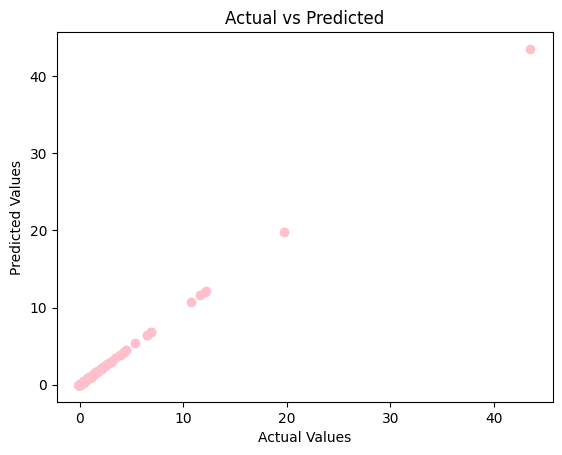

In [25]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, color='pink')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()